# 💳 Scoring crédit — Modelisation
## Notebook 2/3

**Auteur :** Diogo Almeida
**Objectif :** Benchmarker 4 modeles et optimiser le meilleur.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (classification_report, roc_auc_score, f1_score,
    roc_curve, precision_recall_curve, confusion_matrix)
import optuna
import plotly.express as px
import plotly.graph_objects as go
import joblib
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
DATA_PROCESSED = Path('..') / 'data' / 'processed'
MODELS = Path('..') / 'models'
ASSETS = Path('..') / 'assets'
MODELS.mkdir(parents=True, exist_ok=True)

In [2]:
df = pd.read_csv(DATA_PROCESSED / 'credit_encoded.csv')
print(f'Dataset : {len(df)} x {df.shape[1]}')

# Features et cible
exclude = ['target', 'class', 'default']
feature_cols = [c for c in df.columns if c not in exclude and df[c].dtype in ['int64', 'float64']]

X = df[feature_cols].copy()
y = df['target'].copy()

print(f'Features : {len(feature_cols)}')
print(f'Target : {y.value_counts().to_dict()}')
print(f'Taux defaut : {y.mean()*100:.1f}%')

Dataset : 1000 x 26
Features : 24
Target : {0: 700, 1: 300}
Taux defaut : 30.0%


In [3]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)

print(f'Train : {len(X_train)} | Test : {len(X_test)}')

Train : 800 | Test : 200


## 1. Benchmark — 4 modeles

In [4]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                              use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                random_state=42, verbose=-1),
}

results = []
for name, model in models.items():
    # Utiliser les donnees scalees pour LogReg, brutes pour les arbres
    X_tr = X_train_scaled if 'Logistic' in name else X_train
    X_te = X_test_scaled if 'Logistic' in name else X_test
    
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    
    auc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    
    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    X_cv = X_train_scaled if 'Logistic' in name else X_train
    cv_scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring='roc_auc')
    
    results.append({
        'Modele': name, 'AUC': round(auc, 4), 'F1': round(f1, 4),
        'CV_AUC_mean': round(cv_scores.mean(), 4),
        'CV_AUC_std': round(cv_scores.std(), 4),
    })
    print(f'{name:25s} | AUC={auc:.4f} | F1={f1:.4f} | CV={cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

df_results = pd.DataFrame(results).sort_values('AUC', ascending=False)
display(df_results)

Logistic Regression       | AUC=0.7421 | F1=0.5192 | CV=0.7295 +/- 0.0195
Random Forest             | AUC=0.8050 | F1=0.5217 | CV=0.7840 +/- 0.0273
XGBoost                   | AUC=0.7781 | F1=0.5321 | CV=0.7691 +/- 0.0337
LightGBM                  | AUC=0.7592 | F1=0.5370 | CV=0.7727 +/- 0.0375


,Modele,AUC,F1,CV_AUC_mean,CV_AUC_std
1,Random Forest,0.8050,0.5217,0.7840,0.0273
2,XGBoost,0.7781,0.5321,0.7691,0.0337
3,LightGBM,0.7592,0.5370,0.7727,0.0375
0,Logistic Regression,0.7421,0.5192,0.7295,0.0195


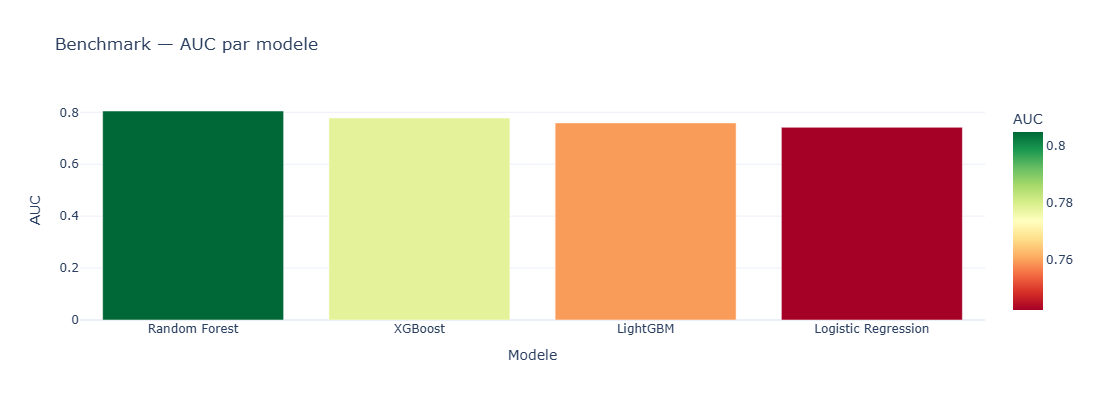

In [5]:
fig = px.bar(df_results, x='Modele', y='AUC',
    title='Benchmark — AUC par modele',
    color='AUC', color_continuous_scale='RdYlGn',
    template='plotly_white', height=400)
fig.show()
fig.write_image(ASSETS / '02_benchmark_auc.png', scale=2)

## 2. Courbes ROC

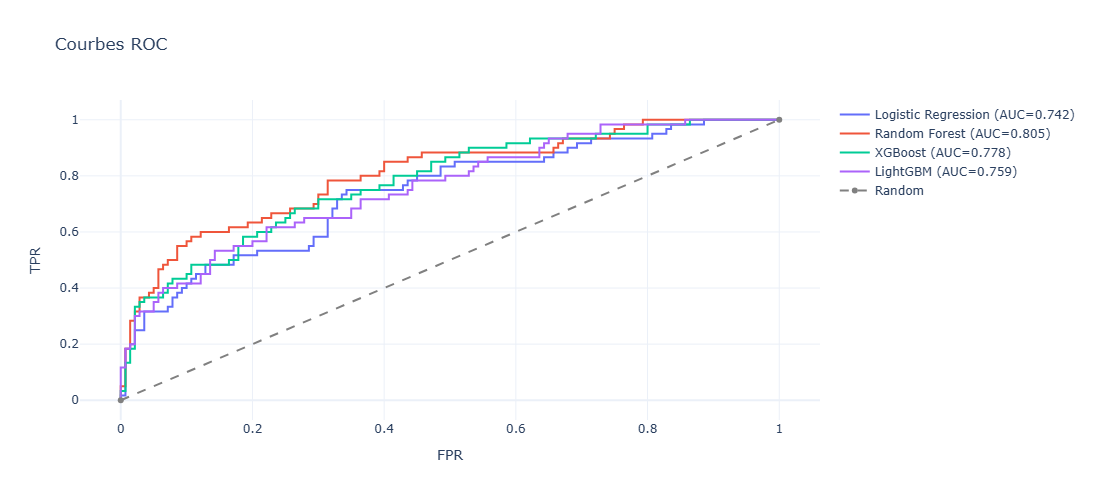

In [6]:
fig = go.Figure()
for name, model in models.items():
    X_te = X_test_scaled if 'Logistic' in name else X_test
    y_prob = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    fig.add_trace(go.Scatter(x=fpr, y=tpr, name=f'{name} (AUC={auc:.3f})', mode='lines'))

fig.add_trace(go.Scatter(x=[0,1], y=[0,1], name='Random', line=dict(dash='dash', color='gray')))
fig.update_layout(title='Courbes ROC', xaxis_title='FPR', yaxis_title='TPR',
                  template='plotly_white', height=500)
fig.show()
fig.write_image(ASSETS / '03_roc_curves.png', scale=2)

## 3. Matrice de confusion du meilleur modele

Meilleur modele : Random Forest

                precision    recall  f1-score   support

    Bon payeur       0.79      0.94      0.86       140
Mauvais payeur       0.75      0.40      0.52        60

      accuracy                           0.78       200
     macro avg       0.77      0.67      0.69       200
  weighted avg       0.78      0.78      0.76       200



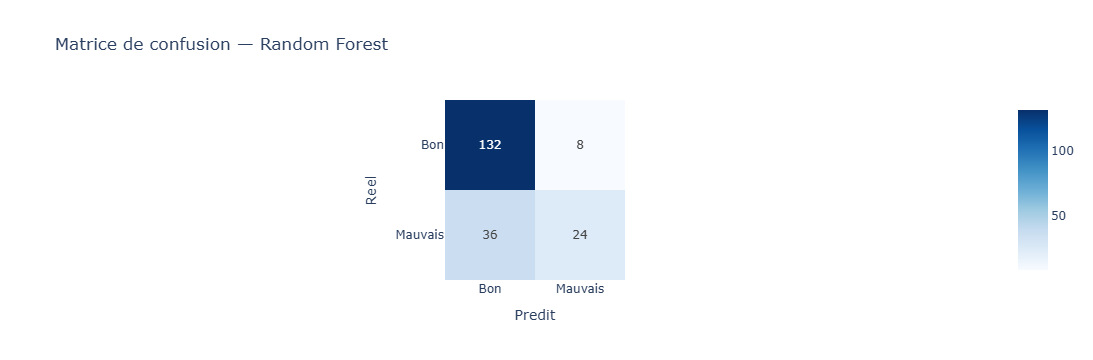

In [7]:
# Meilleur modele
best_name = df_results.iloc[0]['Modele']
best_model = models[best_name]
X_te = X_test_scaled if 'Logistic' in best_name else X_test
y_pred = best_model.predict(X_te)

print(f'Meilleur modele : {best_name}')
print(f'\n{classification_report(y_test, y_pred, target_names=["Bon payeur", "Mauvais payeur"])}')

cm = confusion_matrix(y_test, y_pred)
fig = px.imshow(cm, text_auto=True, title=f'Matrice de confusion — {best_name}',
    labels=dict(x='Predit', y='Reel'),
    x=['Bon', 'Mauvais'], y=['Bon', 'Mauvais'],
    color_continuous_scale='Blues', template='plotly_white')
fig.show()
fig.write_image(ASSETS / '04_confusion_matrix.png', scale=2)

## 4. Sauvegarde

In [8]:
joblib.dump(best_model, MODELS / 'best_model.pkl')
joblib.dump(scaler, MODELS / 'scaler.pkl')
joblib.dump(feature_cols, MODELS / 'feature_cols.pkl')
joblib.dump(models, MODELS / 'all_models.pkl')

print(f'Meilleur modele sauvegarde : {best_name}')
print(f'Features : {len(feature_cols)}')

Meilleur modele sauvegarde : Random Forest
Features : 24
